In [1]:

from analysis import *

TARGET_FEATURES = [
    "TWS",
    "central",
    "COG_Mag",
    "Heel_Abs",
    "lateral",
    "ROT",
    "Trim",
    "TWA_Abs",
    "boat_weight",
    "SOG",
]



df = pd.read_csv("all_data.csv")
drop_cols = [c for c in df.columns if c not in TARGET_FEATURES]
MAX_NULL_RATIO = 0.2

### II.1. All upwind data

In [2]:
upwind_data = df[df['TWA'] >= 0]
df_numeric_upwind = upwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_upwind.columns], inplace=True)
df_numeric_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_upwind)}")

Number of rows after filtering: 44973



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 44973
- Removed samples with NaNs: 2768
- Final samples: 42205

Correlation with SOG:


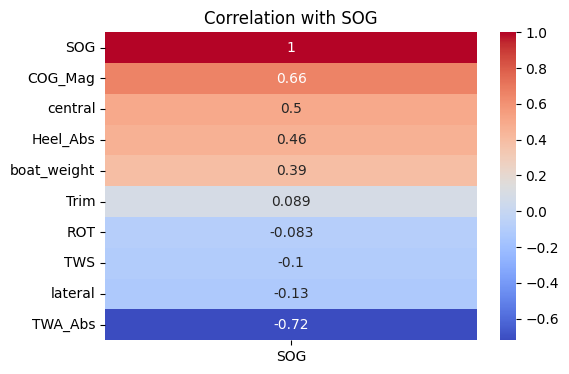


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,43238.098860,1.0,12383.988689,0.000000e+00,0.226900
COG_Mag,15341.380836,1.0,4393.983356,0.000000e+00,0.094314
boat_weight,6822.100408,1.0,1953.943779,0.000000e+00,0.044258
central,5375.055963,1.0,1539.490264,0.000000e+00,0.035201
ROT,1882.609557,1.0,539.205378,1.559063e-118,0.012618
Heel_Abs,1046.305066,1.0,299.676222,6.604512e-67,0.007052
lateral,16.015238,1.0,4.586985,3.222134e-02,0.000109
Trim,1.399970,1.0,0.400971,5.265918e-01,0.000010
TWS,0.301273,1.0,0.086289,7.689507e-01,0.000002
Residual,147321.806187,42195.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.689

Top coefficients:
    feature  coefficient
boat_weight     1.984800
    TWA_Abs    -0.085087
    COG_Mag     0.044499
   Heel_Abs     0.021177
    central     0.019240
    lateral    -0.009671
        ROT    -0.005412
       Trim     0.001573
        TWS     0.001185


,feature,coefficient
8,boat_weight,1.984800
7,TWA_Abs,-0.085087
2,COG_Mag,0.044499
3,Heel_Abs,0.021177
1,central,0.019240
4,lateral,-0.009671
5,ROT,-0.005412
6,Trim,0.001573
0,TWS,0.001185


In [3]:
full_analysis(df_numeric_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### II.2. Upwind: Gian vs Max
#### II.2.1. Upwind: Gian

In [4]:
Gian_data_upwind = upwind_data[(upwind_data['boat_name'] == "Gian Stragiotti")]
df_numeric_Gian_upwind = Gian_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Gian_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Gian_upwind.columns], inplace=True)
df_numeric_Gian_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Gian_upwind)}")

Number of rows after filtering: 20580



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 20580
- Removed samples with NaNs: 57
- Final samples: 20523

Correlation with SOG:


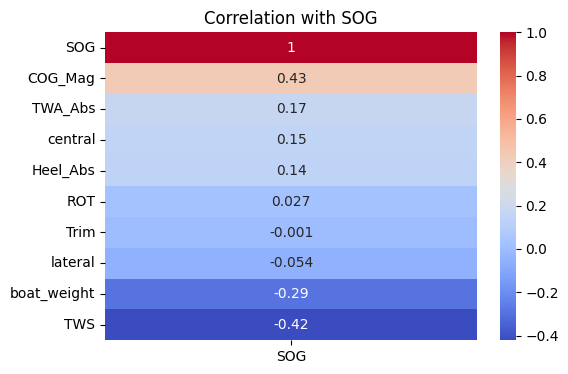


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,1868.014778,1.0,2514.784128,0.000000e+00,0.109207
boat_weight,1397.014426,1.0,1880.707662,0.000000e+00,0.083984
TWS,518.065116,1.0,697.436630,3.614466e-151,0.032882
central,204.423478,1.0,275.201740,2.096309e-61,0.013238
lateral,153.905148,1.0,207.192271,9.513238e-47,0.010000
TWA_Abs,130.479430,1.0,175.655784,6.283979e-40,0.008490
Trim,55.316258,1.0,74.468601,6.602643e-18,0.003617
Heel_Abs,40.417687,1.0,54.411646,1.687813e-13,0.002646
ROT,0.132292,1.0,0.178096,6.730192e-01,0.000009
Residual,15237.326616,20513.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.330

Top coefficients:
    feature  coefficient
boat_weight    -5.851831
        TWS    -0.072976
    lateral    -0.057943
    COG_Mag     0.027195
       Trim    -0.017980
    TWA_Abs     0.009296
   Heel_Abs    -0.008382
    central     0.005409
        ROT     0.000133


,feature,coefficient
8,boat_weight,-5.851831
0,TWS,-0.072976
4,lateral,-0.057943
2,COG_Mag,0.027195
6,Trim,-0.017980
7,TWA_Abs,0.009296
3,Heel_Abs,-0.008382
1,central,0.005409
5,ROT,0.000133


In [5]:
full_analysis(df_numeric_Gian_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.2. Upwind: max

In [6]:
Max_data_upwind = upwind_data[(upwind_data['boat_name'] == "Max Maeder")]
df_numeric_Max_upwind = Max_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_upwind.columns], inplace=True)
df_numeric_Max_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_upwind)}")

Number of rows after filtering: 24393


In [7]:
Max_data_upwind.sample(10)

,ISODateTimeUTC,SecondsSince1970,SOG,TWA,TWS,TWD,BelowLineCalc,central,COG,COG_Mag,...,M_back_X,M_back_Y,M_front_X,M_front_Y,M_tot_X,M_tot_Y,P_back_X,P_back_Y,P_front_X,P_front_Y
66615,2025-11-27T08:49:12.844Z,1.764233e+09,20.8,42.547,15.016,344.346,NaN,115.10,301.8,298.8,...,293.259,-760.193,2663.082,-5181.965,2956.341,-8136.002,-10.458,-2.374,-81.264,-41.110
39744,2025-11-26T14:22:59.055Z,1.764167e+09,20.9,29.111,12.844,338.011,NaN,111.60,308.9,305.9,...,4586.339,-597.750,6076.746,-1182.277,10663.086,2639.323,-8.623,-66.219,-22.909,-118.787
20217,2025-11-26T13:06:32.163Z,1.764162e+09,1.1,118.416,12.784,339.316,NaN,25.70,220.9,217.9,...,17.012,-73.285,23.152,39.555,40.164,-687.050,-622.861,-178.926,26.091,-15.271
42929,2025-11-26T14:32:04.953Z,1.764168e+09,21.2,24.981,15.605,335.681,NaN,102.91,310.7,307.7,...,2594.160,-1089.637,4372.024,-2710.567,6966.184,-2226.880,-17.984,-42.828,-57.022,-92.544
56004,2025-11-27T08:10:57.546Z,1.764231e+09,20.7,40.500,13.800,352.200,NaN,76.00,311.7,308.7,...,6229.238,-1853.599,7347.343,-676.280,13576.581,-1723.271,-20.319,-68.149,-8.758,-95.849
55881,2025-11-27T08:10:45.257Z,1.764231e+09,19.9,38.545,13.600,352.345,NaN,34.90,313.8,310.8,...,5376.723,-1259.167,5993.043,1115.451,11369.766,-1905.612,-24.388,-104.964,21.483,-118.457
51980,2025-11-27T08:01:42.457Z,1.764231e+09,22.3,35.246,11.137,20.346,NaN,85.20,345.1,342.1,...,2108.349,-369.793,5741.902,-1233.870,7850.251,-6634.377,-7.345,-41.443,-21.790,-99.568
3574,2025-11-25T14:08:17.456Z,1.764080e+09,21.2,34.846,25.874,285.246,NaN,NaN,250.4,247.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66422,2025-11-27T08:48:53.556Z,1.764233e+09,20.6,42.322,15.400,349.322,NaN,98.30,307.0,304.0,...,5019.337,-1502.462,7172.771,-177.099,12192.108,-1466.569,-22.898,-76.398,-3.223,-125.563
4016,2025-11-25T14:09:01.650Z,1.764080e+09,19.6,31.230,23.530,290.530,NaN,NaN,259.3,256.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 24393
- Removed samples with NaNs: 2711
- Final samples: 21682

Correlation with SOG:


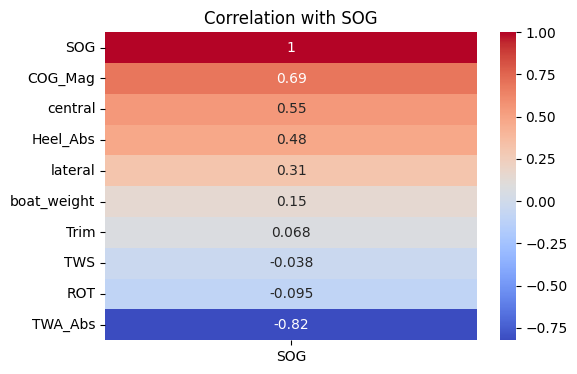


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,36829.947036,1.0,8088.866430,0.000000e+00,0.271795
COG_Mag,6012.963585,1.0,1320.611709,9.653098e-281,0.057436
central,5409.863098,1.0,1188.154302,1.568379e-253,0.051975
boat_weight,2027.033093,1.0,445.192059,7.734302e-98,0.020129
ROT,1590.905093,1.0,349.406389,2.317434e-77,0.015867
Trim,895.608323,1.0,196.700150,1.716290e-44,0.008995
TWS,416.691471,1.0,91.516875,1.220906e-21,0.004205
Heel_Abs,190.991823,1.0,41.947042,9.579121e-11,0.001932
lateral,20.607391,1.0,4.525948,3.339583e-02,0.000209
Residual,98676.201299,21672.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.741

Top coefficients:
    feature  coefficient
boat_weight     6.335487
    TWA_Abs    -0.104931
        TWS     0.061420
       Trim    -0.049894
    COG_Mag     0.037839
    central     0.027670
    lateral    -0.014195
   Heel_Abs     0.010694
        ROT    -0.005303


,feature,coefficient
8,boat_weight,6.335487
7,TWA_Abs,-0.104931
0,TWS,0.061420
6,Trim,-0.049894
2,COG_Mag,0.037839
1,central,0.027670
4,lateral,-0.014195
3,Heel_Abs,0.010694
5,ROT,-0.005303


In [8]:
full_analysis(df_numeric_Max_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.3. Upwind: max vs Gian t_test

In [9]:
t_test(df_numeric_Gian_upwind,df_numeric_Max_upwind)

T-statistic: 88.403, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### II.3. Upwind: Master vs Slave
#### II.3.1. Master

In [10]:
master_data_upwind = upwind_data[upwind_data['boat_role'] == "master"]
df_numeric_master_upwind = master_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_upwind.columns], inplace=True)
df_numeric_master_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_upwind)}")

Number of rows after filtering: 22510



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 22510
- Removed samples with NaNs: 1257
- Final samples: 21253

Correlation with SOG:


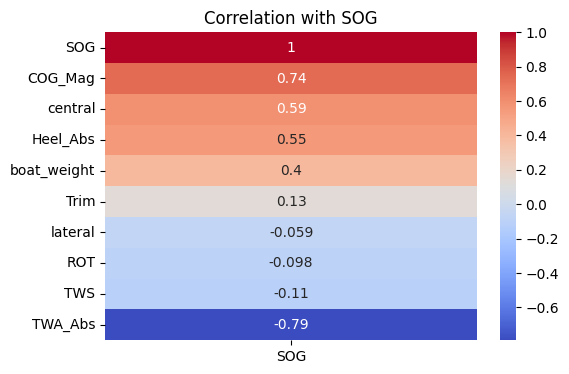


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,29753.723818,1.0,6868.144589,0.000000e+00,0.244321
COG_Mag,7713.165075,1.0,1780.453879,0.000000e+00,0.077332
central,5495.278362,1.0,1268.492192,6.661739e-270,0.056349
boat_weight,4015.366897,1.0,926.879627,2.661383e-199,0.041808
ROT,1519.070573,1.0,350.651784,1.289315e-77,0.016239
Heel_Abs,406.861427,1.0,93.917088,3.657010e-22,0.004402
lateral,67.148805,1.0,15.500167,8.276096e-05,0.000729
TWS,51.914278,1.0,11.983534,5.377824e-04,0.000564
Trim,1.921789,1.0,0.443613,5.053912e-01,0.000021
Residual,92027.526045,21243.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.765

Top coefficients:
    feature  coefficient
boat_weight     2.146530
    TWA_Abs    -0.092217
    COG_Mag     0.042455
    lateral    -0.027576
    central     0.027234
        TWS    -0.022572
   Heel_Abs     0.017213
        ROT    -0.005322
       Trim    -0.002486


,feature,coefficient
8,boat_weight,2.146530
7,TWA_Abs,-0.092217
2,COG_Mag,0.042455
4,lateral,-0.027576
1,central,0.027234
0,TWS,-0.022572
3,Heel_Abs,0.017213
5,ROT,-0.005322
6,Trim,-0.002486


In [11]:
full_analysis(df_numeric_master_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.3.2 Slave

In [12]:
slave_data_upwind = upwind_data[upwind_data['boat_role'] == "slave"]
df_numeric_slave_upwind = slave_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_upwind.columns], inplace=True)
df_numeric_slave_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_upwind)}")

Number of rows after filtering: 22463



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 22463
- Removed samples with NaNs: 1511
- Final samples: 20952

Correlation with SOG:


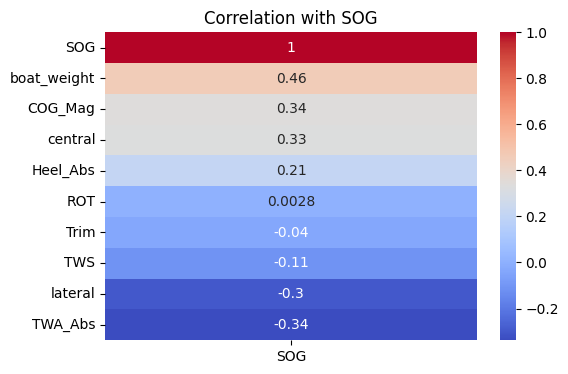


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,3183.532738,1.0,1417.326978,3.458495e-300,0.063389
COG_Mag,3046.953539,1.0,1356.521138,8.540801e-288,0.060835
boat_weight,2821.954804,1.0,1256.350415,2.640653e-267,0.056597
central,1121.792000,1.0,499.428213,2.401341e-109,0.023293
Heel_Abs,101.634642,1.0,45.248324,1.780475e-11,0.002156
ROT,81.654433,1.0,36.353020,1.673820e-09,0.001733
Trim,63.332940,1.0,28.196187,1.107382e-07,0.001345
lateral,24.938533,1.0,11.102777,8.634773e-04,0.000530
TWS,1.687553,1.0,0.751308,3.860723e-01,0.000036
Residual,47038.928638,20942.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.383

Top coefficients:
    feature  coefficient
boat_weight     1.821738
    TWA_Abs    -0.043652
    COG_Mag     0.031696
    lateral    -0.017566
       Trim    -0.016079
    central     0.012718
   Heel_Abs     0.010695
        TWS     0.003906
        ROT    -0.002793


,feature,coefficient
8,boat_weight,1.821738
7,TWA_Abs,-0.043652
2,COG_Mag,0.031696
4,lateral,-0.017566
6,Trim,-0.016079
1,central,0.012718
3,Heel_Abs,0.010695
0,TWS,0.003906
5,ROT,-0.002793


In [13]:
full_analysis(df_numeric_slave_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Upwind: Master vs Slave t_test

In [14]:
t_test(df_numeric_master_upwind,df_numeric_slave_upwind)

T-statistic: -25.815, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


## III Downwind
### III.1. All downwind data

In [15]:
downwind_data = df[df['TWA'] < 0]
df_numeric_downwind = downwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_downwind.columns], inplace=True)
df_numeric_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_downwind)}")

Number of rows after filtering: 31827



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 31827
- Removed samples with NaNs: 990
- Final samples: 30837

Correlation with SOG:


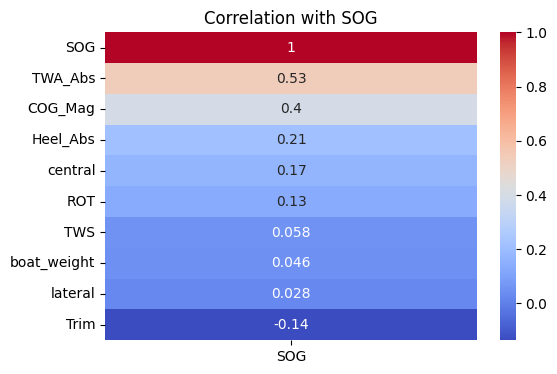


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,64513.495225,1.0,4565.144323,0.000000e+00,0.128988
ROT,7945.931896,1.0,562.275006,3.418186e-123,0.017913
Heel_Abs,7872.481661,1.0,557.077474,4.408324e-122,0.017750
boat_weight,7541.679210,1.0,533.669024,4.447504e-117,0.017017
lateral,5368.519066,1.0,379.890506,4.222858e-84,0.012173
TWS,4862.868345,1.0,344.109333,2.119941e-76,0.011039
COG_Mag,3330.559389,1.0,235.679128,5.409692e-53,0.007587
Trim,1474.534995,1.0,104.341968,1.862355e-24,0.003373
central,859.330150,1.0,60.808458,6.488293e-15,0.001969
Residual,435639.571625,30827.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.353

Top coefficients:
    feature  coefficient
boat_weight     2.500372
    lateral     0.299124
        TWS     0.199404
    TWA_Abs     0.136121
   Heel_Abs     0.080418
       Trim    -0.063654
    COG_Mag     0.024621
    central     0.016111
        ROT     0.012318


,feature,coefficient
8,boat_weight,2.500372
4,lateral,0.299124
0,TWS,0.199404
7,TWA_Abs,0.136121
3,Heel_Abs,0.080418
6,Trim,-0.063654
2,COG_Mag,0.024621
1,central,0.016111
5,ROT,0.012318


In [16]:

full_analysis(df_numeric_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### III.2. Downwind: Gian vs max
#### III.2.1. Downwind: Gian

In [17]:
gian_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Gian Stragiotti") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "max Maeder"))
]
df_numeric_gian_downwind = gian_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_gian_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_gian_downwind.columns], inplace=True)
df_numeric_gian_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_gian_downwind)}")

Number of rows after filtering: 15444



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 15444
- Removed samples with NaNs: 50
- Final samples: 15394

Correlation with SOG:


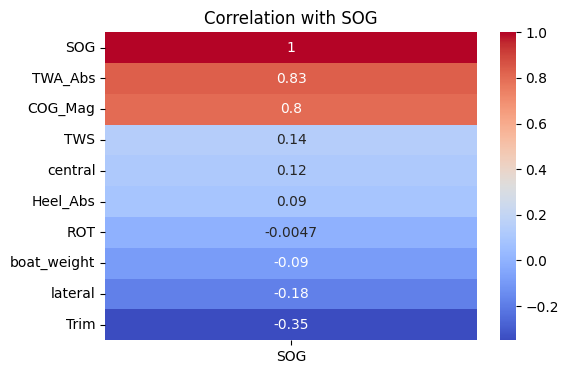


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,11434.970058,1.0,5235.726183,0.000000e+00,0.253918
TWA_Abs,9316.041208,1.0,4265.532890,0.000000e+00,0.217081
boat_weight,7165.201735,1.0,3280.728689,0.000000e+00,0.175772
TWS,2064.862872,1.0,945.438121,1.544028e-201,0.057898
Trim,1190.306492,1.0,545.005263,1.746600e-118,0.034215
lateral,151.886785,1.0,69.544355,8.098664e-17,0.004500
ROT,43.121750,1.0,19.744142,8.915091e-06,0.001282
Heel_Abs,4.340415,1.0,1.987345,1.586390e-01,0.000129
central,4.308227,1.0,1.972606,1.601917e-01,0.000128
Residual,33599.079331,15384.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.811

Top coefficients:
    feature  coefficient
boat_weight   -15.149731
        TWS     0.196392
    lateral    -0.109087
       Trim    -0.093062
    TWA_Abs     0.088770
    COG_Mag     0.085507
        ROT    -0.004640
   Heel_Abs    -0.003578
    central    -0.002012


,feature,coefficient
8,boat_weight,-15.149731
0,TWS,0.196392
4,lateral,-0.109087
6,Trim,-0.093062
7,TWA_Abs,0.088770
2,COG_Mag,0.085507
5,ROT,-0.004640
3,Heel_Abs,-0.003578
1,central,-0.002012


In [18]:

full_analysis(df_numeric_gian_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.2. Downwind: max

In [19]:
Max_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Max Maeder") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "Gian Stragiotti"))
]
df_numeric_Max_downwind = Max_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_downwind.columns], inplace=True)
df_numeric_Max_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_downwind)}")

Number of rows after filtering: 16383



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 16383
- Removed samples with NaNs: 940
- Final samples: 15443

Correlation with SOG:


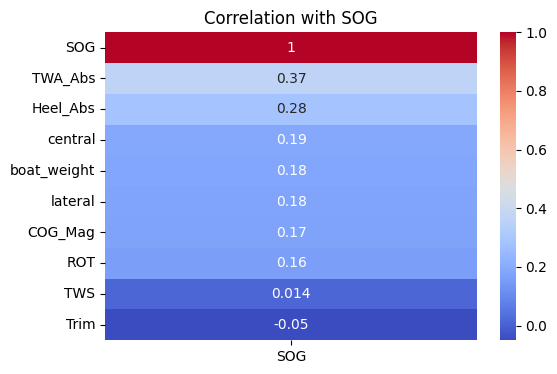


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,35724.404078,1.0,1520.813261,2.324537e-317,0.089703
boat_weight,13188.800103,1.0,561.456590,6.037704e-122,0.035103
Heel_Abs,12665.485517,1.0,539.178716,2.886339e-117,0.033757
ROT,8397.227027,1.0,357.475920,7.754189e-79,0.022639
TWS,5428.984741,1.0,231.115737,8.078148e-52,0.014754
lateral,3937.374562,1.0,167.616832,3.874986e-38,0.010744
Trim,969.449468,1.0,41.270153,1.364603e-10,0.002667
COG_Mag,430.720280,1.0,18.336068,1.862870e-05,0.001187
central,175.149017,1.0,7.456218,6.328944e-03,0.000483
Residual,362526.249897,15433.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.267

Top coefficients:
    feature  coefficient
boat_weight    19.166120
    lateral     0.345237
        TWS     0.290073
    TWA_Abs     0.133735
   Heel_Abs     0.123985
       Trim    -0.070739
        ROT     0.012920
    COG_Mag     0.010989
    central     0.010110


,feature,coefficient
8,boat_weight,19.166120
4,lateral,0.345237
0,TWS,0.290073
7,TWA_Abs,0.133735
3,Heel_Abs,0.123985
6,Trim,-0.070739
5,ROT,0.012920
2,COG_Mag,0.010989
1,central,0.010110


In [20]:
full_analysis(df_numeric_Max_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.3. Downwind: Max vs Gian t_test

In [21]:
t_test(df_numeric_Max_downwind,df_numeric_gian_downwind)

T-statistic: -8.510, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### III.3. Downwind: Master vs Slave
#### III.3.1 Downwind Master

In [22]:
master_data_downwind = downwind_data[downwind_data['boat_role'] == "master"]
df_numeric_master_downwind = master_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_downwind.columns], inplace=True)
df_numeric_master_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_downwind)}")

Number of rows after filtering: 16019



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 16019
- Removed samples with NaNs: 495
- Final samples: 15524

Correlation with SOG:


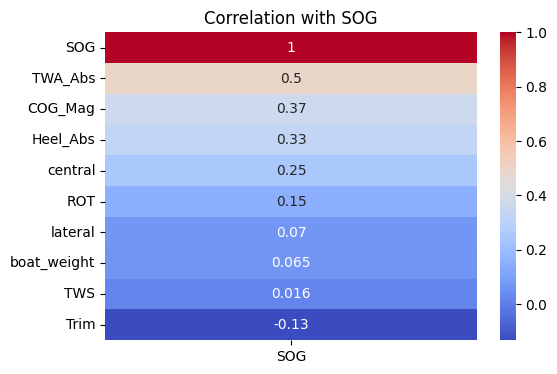


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,56153.134898,1.0,2527.513538,0.000000e+00,0.140094
Heel_Abs,15689.733193,1.0,706.211917,3.330269e-152,0.043539
boat_weight,15019.129347,1.0,676.027310,6.404732e-146,0.041756
lateral,12768.300345,1.0,574.715054,9.718076e-125,0.035722
ROT,9424.133937,1.0,424.190495,5.223760e-93,0.026615
TWS,1195.307618,1.0,53.802093,2.326987e-13,0.003456
Trim,971.161512,1.0,43.713034,3.926453e-11,0.002810
central,263.073864,1.0,11.841240,5.808582e-04,0.000763
COG_Mag,26.748339,1.0,1.203972,2.725463e-01,0.000078
Residual,344670.650312,15514.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.380

Top coefficients:
    feature  coefficient
boat_weight     4.856853
    lateral     0.663782
    TWA_Abs     0.159483
   Heel_Abs     0.151550
        TWS     0.137956
       Trim    -0.070905
        ROT     0.016364
    central     0.012125
    COG_Mag    -0.002837


,feature,coefficient
8,boat_weight,4.856853
4,lateral,0.663782
7,TWA_Abs,0.159483
3,Heel_Abs,0.151550
0,TWS,0.137956
6,Trim,-0.070905
5,ROT,0.016364
1,central,0.012125
2,COG_Mag,-0.002837


In [23]:
full_analysis(df_numeric_master_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.2 Downwind Slave

In [24]:
slave_data_downwind = downwind_data[downwind_data['boat_role'] == "slave"]
df_numeric_slave_downwind = slave_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_downwind.columns], inplace=True)
df_numeric_slave_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_downwind)}")

Number of rows after filtering: 15808



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 15808
- Removed samples with NaNs: 495
- Final samples: 15313

Correlation with SOG:


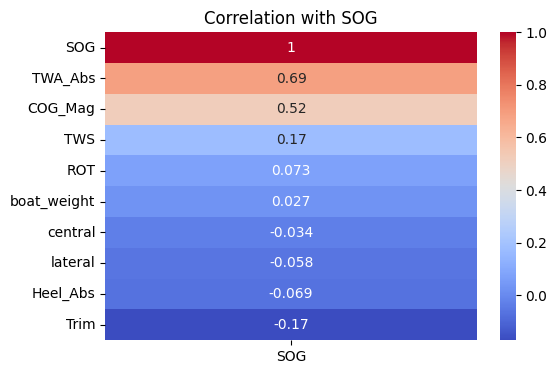


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,12628.632891,1.0,4222.524182,0.000000e+00,0.216257
COG_Mag,6243.209738,1.0,2087.486771,0.000000e+00,0.120036
TWS,2523.199294,1.0,843.659811,1.328110e-180,0.052250
ROT,620.772464,1.0,207.562193,9.453380e-47,0.013382
Heel_Abs,428.871722,1.0,143.398041,6.748519e-33,0.009284
Trim,323.097396,1.0,108.031216,3.209891e-25,0.007010
central,266.745814,1.0,89.189437,4.095235e-21,0.005794
boat_weight,82.184647,1.0,27.479353,1.608913e-07,0.001792
lateral,5.486181,1.0,1.834366,1.756327e-01,0.000120
Residual,45767.877408,15303.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.557

Top coefficients:
    feature  coefficient
boat_weight    -0.393068
        TWS     0.214556
    TWA_Abs     0.104036
    COG_Mag     0.056354
       Trim    -0.044271
   Heel_Abs    -0.028968
    lateral    -0.013472
    central     0.013355
        ROT     0.006245


,feature,coefficient
8,boat_weight,-0.393068
0,TWS,0.214556
7,TWA_Abs,0.104036
2,COG_Mag,0.056354
6,Trim,-0.044271
3,Heel_Abs,-0.028968
4,lateral,-0.013472
1,central,0.013355
5,ROT,0.006245


In [25]:
full_analysis(df_numeric_slave_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Downwind: Master vs Slave t_test

In [26]:
t_test(df_numeric_master_downwind,df_numeric_slave_downwind)

T-statistic: -24.535, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.
